In [1]:
import numpy as np
import os
import torch
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from accelerate import Accelerator
from torch_ema import ExponentialMovingAverage as EMA
from torchvision import transforms as tf
import torch.distributed as dist

from wavediffusion.model_unet import myUnet
from wavediffusion.model import Scaled, PredX0
from wavediffusion.wavedata import npyDataWndHist
from wavediffusion.diffusion import ScheduleLogLinear, ScheduleDDPM, samples, samples_onestep, masked_training_loop

from wavediffusion.waveutils import evaluate, sample_and_save

%load_ext autoreload
%autoreload 2

In [2]:
train_file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/train_global/'
train_file_names = [
    *( (f'waveparts_2010{i:02d}', f'forcing_2010{i:02d}') for i in range(1, 13) ),
    *( (f'waveparts_2011{i:02d}', f'forcing_2011{i:02d}') for i in range(1, 13) ),
    *( (f'waveparts_2012{i:02d}', f'forcing_2012{i:02d}') for i in range(1, 13) ),
    *( (f'waveparts_2013{i:02d}', f'forcing_2013{i:02d}') for i in range(1, 13) ),
    *( (f'waveparts_2014{i:02d}', f'forcing_2014{i:02d}') for i in range(1, 13) ),
    *( (f'waveparts_2015{i:02d}', f'forcing_2015{i:02d}') for i in range(1, 13) ),
    *( (f'waveparts_2016{i:02d}', f'forcing_2016{i:02d}') for i in range(1, 13) ),
    *( (f'waveparts_2017{i:02d}', f'forcing_2017{i:02d}') for i in range(1, 13) ),
    *( (f'waveparts_2018{i:02d}', f'forcing_2018{i:02d}') for i in range(1, 13) ),
    *( (f'waveparts_2019{i:02d}', f'forcing_2019{i:02d}') for i in range(1, 13) ),
    *( (f'waveparts_2020{i:02d}', f'forcing_2020{i:02d}') for i in range(1, 13) ),
    *( (f'waveparts_2021{i:02d}', f'forcing_2021{i:02d}') for i in range(1, 13) ),
    *( (f'waveparts_2022{i:02d}', f'forcing_2022{i:02d}') for i in range(1, 13) ),
]
train_file_list = [(os.path.join(train_file_path, f'{x}.npy'), 
                    os.path.join(train_file_path, f'{f}.npy')) for x, f in train_file_names]   
stats_file1 = os.path.join(train_file_path, 'stats.npz')
stats = np.load(stats_file1)
meanf, stdf = stats['meanf'], stats['stdf']
stats_file2 = os.path.join(train_file_path, 'stats_parts.npz')
stats_parts = np.load(stats_file2)
meanx, stdx = stats_parts['meanparts'], stats_parts['stdparts']
train = npyDataWndHist(
    train_file_list,
    resize_x=(320,320), resize_f=(320,320), 
    landmaskname=os.path.join(train_file_path, 'mask.npy'),
    use_icymask=True, compute_stats=False,
    meanx=meanx, stdx=stdx, meanf=meanf, stdf=stdf,
    OPTION=3
)

In [3]:
import torchvision.transforms as tf 
x, f, icymask = train.__getitem__(0)
x_truth = train.invert_x(x) * tf.Resize((320,720))(icymask)
f_  = train.invert_f(f)

/global/u1/j/jiarongw/wavediffusion/src/wavediffusion/wavedata.py:397: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /mscratch/sd/s/swowner/pytorch-build/pytorch/2.6.0/pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  f = torch.from_numpy(self.F_files[file_idx][local_idx]).float()


In [11]:
def plot_crossing_frac(x_true, x_sample):
    fig, axes = plt.subplots(1, 2, figsize=[25, 5], dpi=100)
    
    img1 = axes[0].imshow(x_true[6], vmin=0, vmax=1, cmap='binary')
    img2 = axes[1].imshow(x_sample[6], vmin=0, vmax=1, cmap='binary')

    axes[0].set_title(f"Truth", fontsize=14)
    axes[1].set_title(f"Sampled", fontsize=14)
    axes[0].set_xticks([]); axes[0].set_yticks([])
    axes[1].set_xticks([]); axes[1].set_yticks([])
    fig.colorbar(img1, ax=axes[0], fraction=0.046, pad=0.04)
    fig.colorbar(img2, ax=axes[1], fraction=0.046, pad=0.04)
        
    plt.tight_layout()  # leave room on the left for text
    return fig

In [4]:
def plot_sample_parts(x_true, x_sample):
    fig, axes = plt.subplots(4, 3, figsize=[35, 15], dpi=100)
    titles = ['wave height','wave period','direction']
    
    imgs = [
        axes[0, 0].imshow(x_true[0], vmin=0, vmax=10, cmap='Blues'),
        axes[0, 1].imshow(x_true[1], vmin=0, vmax=20, cmap='Reds'),
        axes[0, 2].imshow(x_true[2], vmin=0, vmax=360, cmap='twilight_r'),
    ]
    axes[0, 0].set_ylabel(f"Truth partition 1", fontsize=14, labelpad=40)
    for j in range(3):
        axes[0,j].set_xticks([]); axes[0,j].set_yticks([])
        axes[0,j].set_title(titles[j])
        fig.colorbar(imgs[j], ax=axes[0,j], fraction=0.046, pad=0.04)
        
    imgs = [
        axes[1, 0].imshow(x_sample[0], vmin=0, vmax=10, cmap='Blues'),
        axes[1, 1].imshow(x_sample[1], vmin=0, vmax=20, cmap='Reds'),
        axes[1, 2].imshow(x_sample[2], vmin=0, vmax=360, cmap='twilight_r'),
    ]
    axes[1, 0].set_ylabel(f"Sampled partition 1", fontsize=14, labelpad=40)
    for j in range(3):
        axes[1,j].set_xticks([]); axes[1,j].set_yticks([])
        fig.colorbar(imgs[j], ax=axes[1,j], fraction=0.046, pad=0.04)  
        
    imgs = [
        axes[2, 0].imshow(x_true[3], vmin=0, vmax=10, cmap='Blues'),
        axes[2, 1].imshow(x_true[4], vmin=0, vmax=20, cmap='Reds'),
        axes[2, 2].imshow(x_true[5], vmin=0, vmax=360, cmap='twilight_r'),
    ]
    axes[2, 0].set_ylabel(f"Truth partition 2", fontsize=14, labelpad=40)
    for j in range(3):
        axes[2,j].set_xticks([]); axes[2,j].set_yticks([])
        fig.colorbar(imgs[j], ax=axes[2,j], fraction=0.046, pad=0.04)  

    imgs = [
        axes[3, 0].imshow(x_sample[3], vmin=0, vmax=10, cmap='Blues'),
        axes[3, 1].imshow(x_sample[4], vmin=0, vmax=20, cmap='Reds'),
        axes[3, 2].imshow(x_sample[5], vmin=0, vmax=360, cmap='twilight_r'),
    ]
    axes[3, 0].set_ylabel(f"Sampled partition 2", fontsize=14, labelpad=40)
    for j in range(3):
        axes[3,j].set_xticks([]); axes[3,j].set_yticks([])
        fig.colorbar(imgs[j], ax=axes[3,j], fraction=0.046, pad=0.04)  
        
    plt.tight_layout(rect=[0.12, 0, 1, 1])  # leave room on the left for text
    return fig

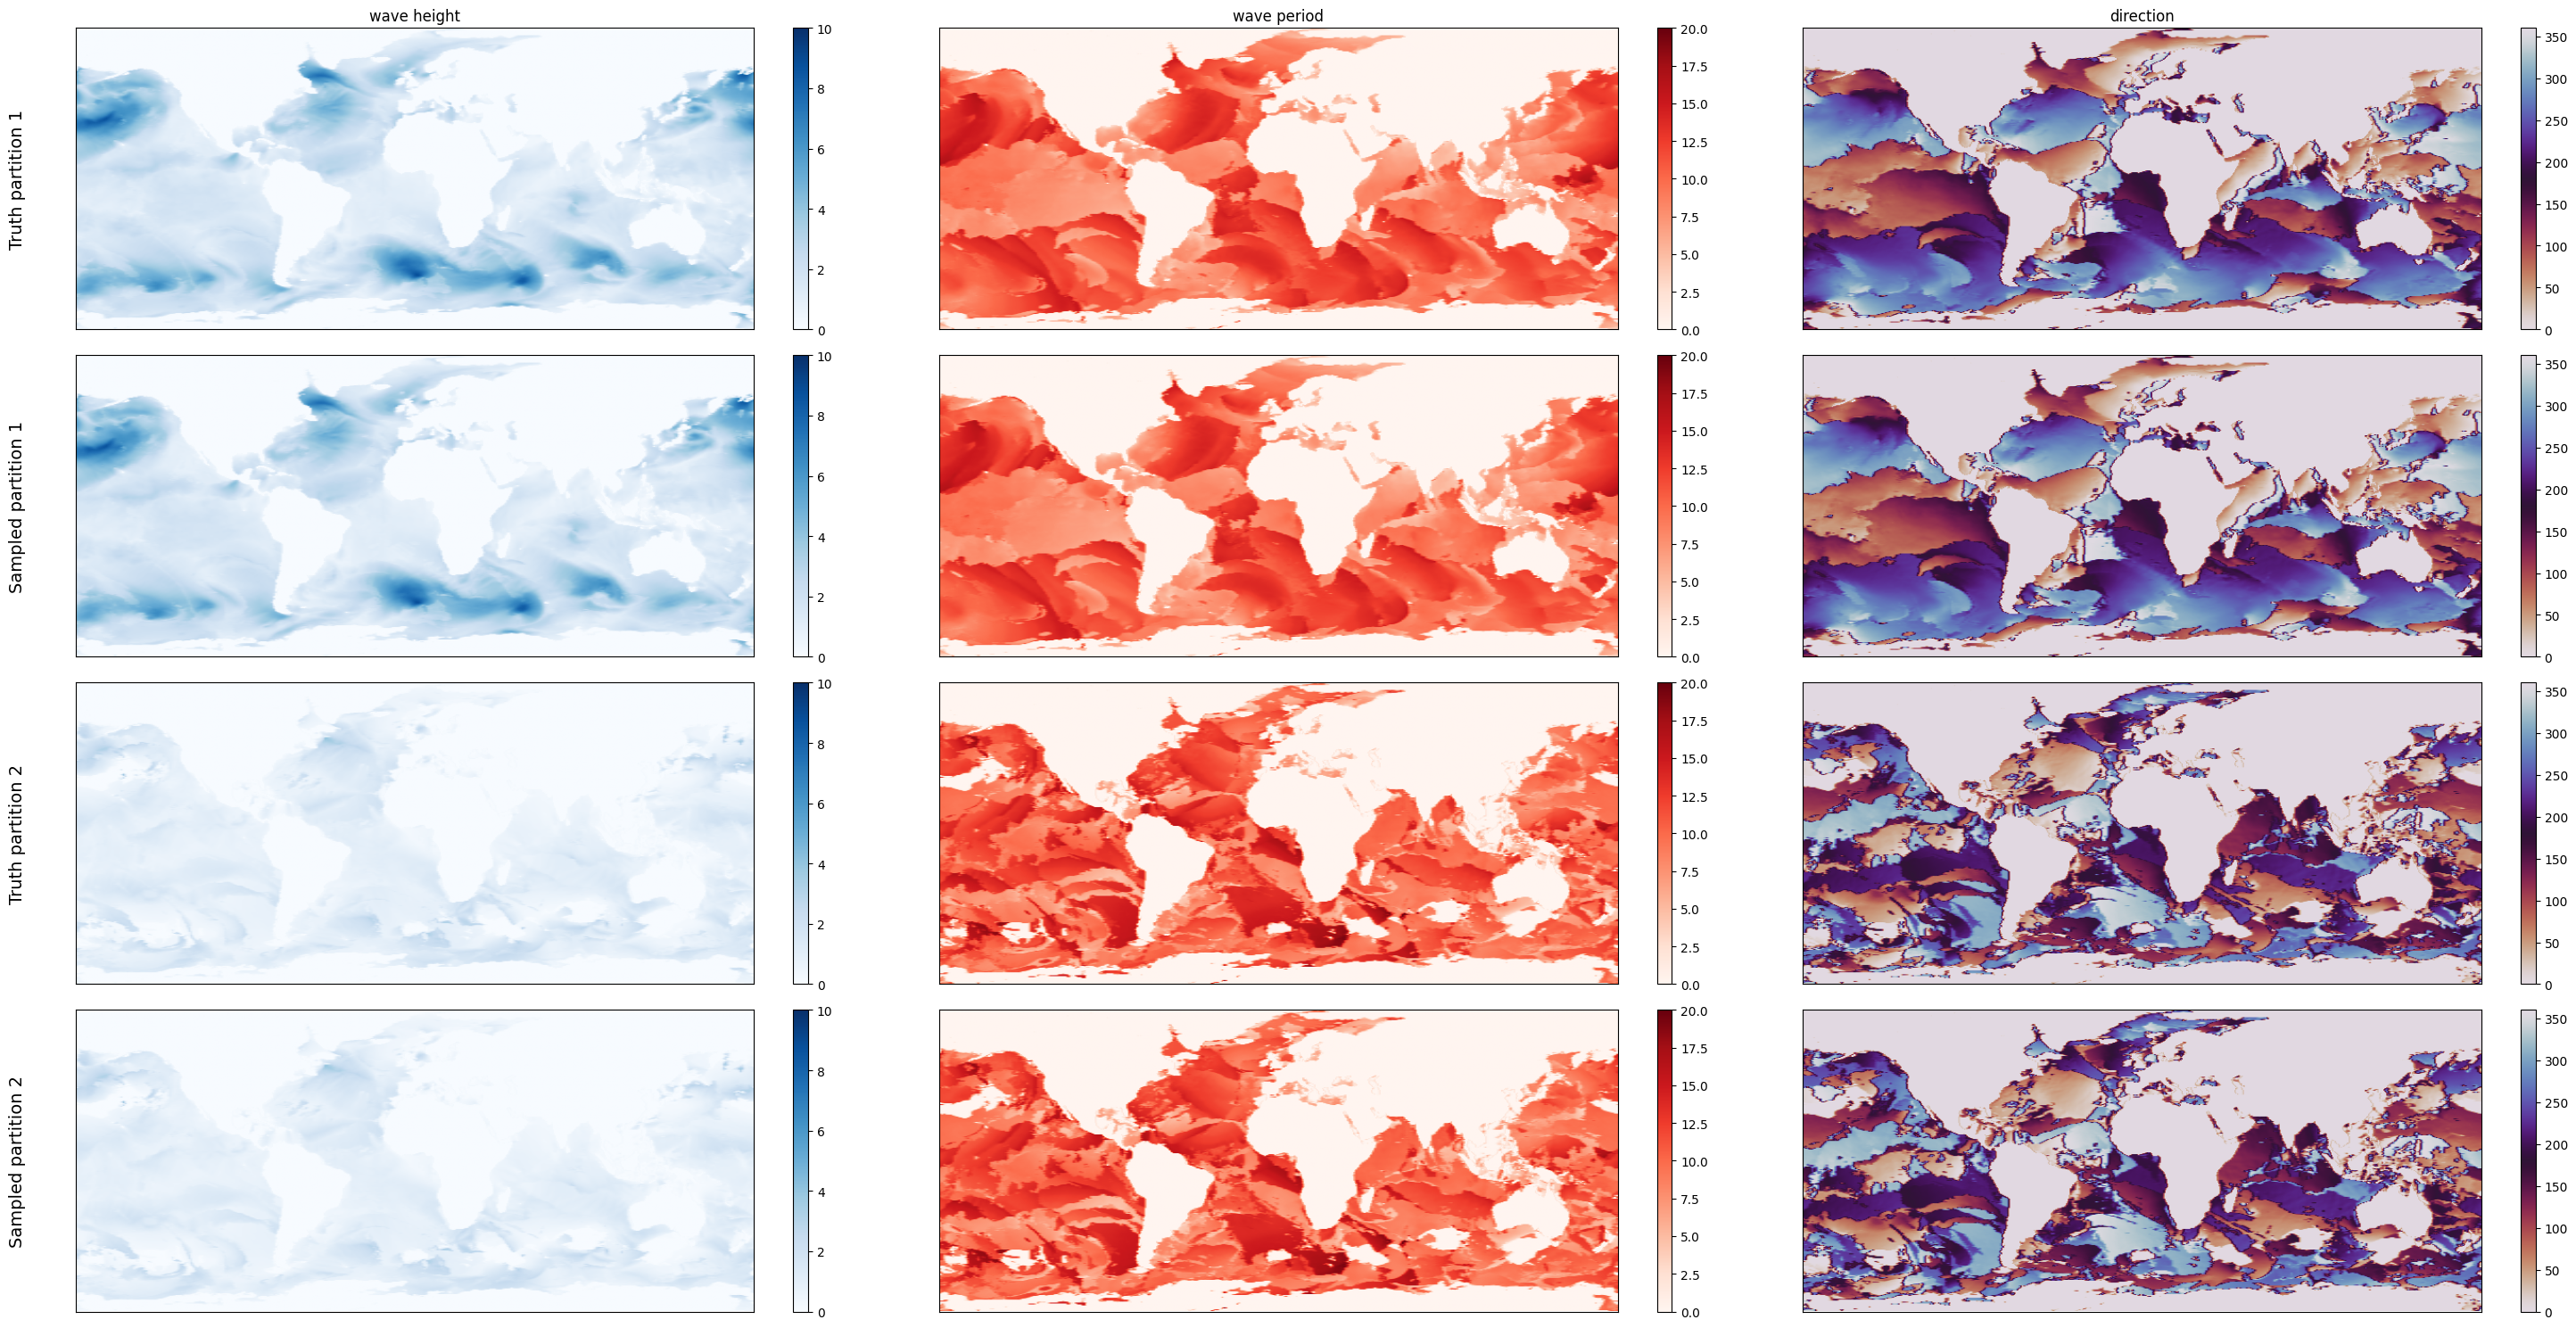

In [5]:
fig = plot_sample_parts(x_truth.cpu().numpy()[:,::-1], x_truth.cpu().numpy()[:,::-1])

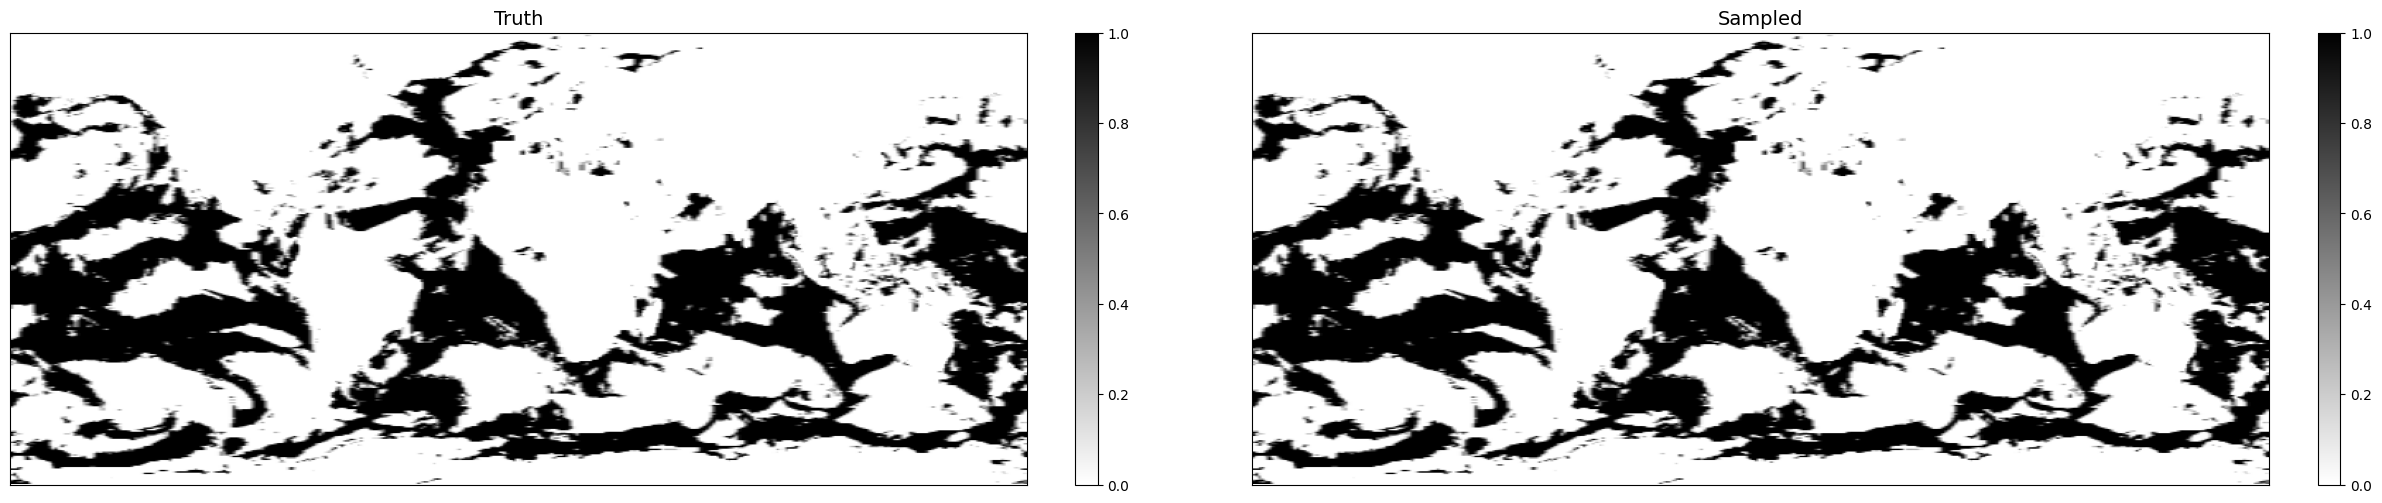

In [12]:
fig = plot_crossing_frac(x_truth.cpu().numpy()[:,::-1], x_truth.cpu().numpy()[:,::-1])

In [2]:
train_file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/train_global/'
test_file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/test_global/'
test_file_names = [*( (f'wave_2004{i:02d}', f'forcing_2004{i:02d}') for i in range(1, 13) )]
# test_file_names = [('wave_200409', 'forcing_200409')]
test_file_list = [(os.path.join(test_file_path, f'{x}.npy'), 
                   os.path.join(test_file_path, f'{f}.npy')) for x, f in test_file_names]
stats_file = os.path.join(train_file_path, 'stats.npz')
stats = np.load(stats_file)
meanx, stdx = stats['meanx'], stats['stdx']
meanf, stdf = stats['meanf'], stats['stdf']
test = npyDataWndHist(
    test_file_list,
    resize_x=(320,320), resize_f=(320,320), 
    landmaskname=os.path.join(test_file_path, 'mask.npy'),
    use_icymask=True, compute_stats=False,
    meanx=meanx, stdx=stdx, meanf=meanf, stdf=stdf
)

In [3]:
### Predicting epsilon
n_ensem = 20
epoch = 16
RESUME = True
path = '/global/homes/j/jiarongw/scratch_folder/log1p/hist1/'
weights_file = path + f'ckpt_{epoch}.pt'
model = Scaled(myUnet)(in_dim=320, in_ch=4, out_ch=4, ch=256, precond_ch=13, 
                       scale=(test.meanx, test.stdx, test.meanf, test.stdf),
                       ch_mult=(1, 2, 2), attn_resolutions=(16,))  

ema = EMA(model.parameters(), decay=0.999)
if RESUME:
    ckpt = torch.load(weights_file, map_location="cpu")
    model.load_state_dict(ckpt["model"])
    ema.load_state_dict(ckpt["ema"])
a = Accelerator()
model = a.prepare(model)
ema.to(a.device)

In [3]:
### Predicting state
n_ensem = 20
epoch = 12
RESUME = True
path = '/global/homes/j/jiarongw/scratch_folder/log1p/hist1_PredX0/'
weights_file = path + f'ckpt_{epoch}.pt'
model = PredX0(Scaled(myUnet))(in_dim=320, in_ch=4, out_ch=4, ch=256, precond_ch=13, 
                       scale=(test.meanx, test.stdx, test.meanf, test.stdf),
                       ch_mult=(1, 2, 2), attn_resolutions=(16,))  

ema = EMA(model.parameters(), decay=0.999)
if RESUME:
    ckpt = torch.load(weights_file, map_location="cpu")
    model.load_state_dict(ckpt["model"])
    ema.load_state_dict(ckpt["ema"])
a = Accelerator()
model = a.prepare(model)
ema.to(a.device)

In [4]:
# Given one data point, infer conditional mean (unnormalized) 
# Also return the unnormalized x_truth and forcing for evaluation
@torch.no_grad()
def sample_onestep (f, x, mask, sigma_max=20):
    global a, test, ema, model
    with ema.average_parameters():
        x0 = samples_onestep(model, sigma_max=sigma_max, batchsize=1, cond=f, 
                             accelerator=a, mask=mask)   
    x_pred = test.invert_x(x0[0])
    x_pred = x_pred * tf.Resize((320,720))(mask[0].to(x_pred))
    x_truth = test.invert_x(x[0]) * tf.Resize((320,720))(mask[0].to(x))
    x_truth = x_truth.cpu().numpy()
    f_ = test.invert_f(f[0]).cpu().numpy()
    return x_pred.cpu().numpy(), x_truth, f_

In [5]:
wlat = np.load('/global/homes/j/jiarongw/scratch_folder/wave_data/wlat.npy')
# weighted and masked RMSE
def weighted_mse(a, b, mask, w):
    diff2 = (a - b) ** 2
    return np.sum(diff2[mask] * w[mask]) / np.sum(w[mask])
# weighted and masked spread / skill
def weighted_meanvar(std, mask, w):
    var = std ** 2
    return np.sum(var[mask] * w[mask]) / np.sum(w[mask])  

In [6]:
from torch import nn
from typing import Optional, Union, Tuple
@torch.no_grad()
def samples_onestep(model      : nn.Module,
            sigma_max : float = 20.,   # A high noise level to probe model behavior
            batchsize  : int = 1,
            cond       : Optional[torch.Tensor] = None, 
            accelerator: Optional[Accelerator] = None, 
            mask       : Optional[torch.FloatTensor] = None):
    model.eval()
    accelerator = accelerator or Accelerator()
    sigma0 = torch.tensor([sigma_max]).to(accelerator.device) # A very large noise level 
    xt = model.rand_input(batchsize).to(accelerator.device) * sigma0 * mask.to(accelerator.device) # Use randomly generated noise to probe the high noise level?
    # xt = torch.zeros((batchsize,) + model.input_dims).to(accelerator.device) * sigma0 * mask.to(accelerator.device) # Use 0 to probe the high noise level?
    eps = model.predict_eps(xt, sigma0, cond=cond.to(accelerator.device)) * mask.to(accelerator.device)
    x0 = xt - eps * sigma0
    # x0 = model.forward(xt, sigma0, cond=f.to(a.device)) * mask.to(a.device) # Only works if model is predicting state    
    return x0

In [9]:
from tqdm import tqdm
hs_mse, lp_mse, tp_mse, thetap_mse, spread_mse = [], [], [], [], []
x_truth, mean, std = None, None, None
for index in tqdm(range(0, test.__len__(), 80)):
    print(f'Infering conditional mean for index {index}...')
    x, f, icymask = test.__getitem__(index)
    x = x.unsqueeze(0); f = f.unsqueeze(0); icymask = icymask.unsqueeze(0)
    x_pred, x_truth, f_ = sample_onestep (f, x, icymask, sigma_max=120)
    # Lower bound the wave length with 0?
    x_pred[1] = np.maximum(x_pred[1], 0)
    x_truth[1] = np.maximum(x_truth[1], 0) 
    # Use the ice mask?
    icymask = f_[2] == 1
    hs_mse.append(weighted_mse(x_truth[0], x_pred[0], icymask, wlat))
    lp_mse.append(weighted_mse(x_truth[1], x_pred[1], icymask, wlat))
    tp_mse.append(weighted_mse((x_truth[1]/1.56)**0.5, (x_pred[1]/1.56)**0.5, icymask, wlat))
    thetap_mse.append(weighted_mse(x_truth[2], x_pred[2], icymask, wlat))
    spread_mse.append(weighted_mse(x_truth[3], x_pred[3], icymask, wlat))  

  3%|▎         | 1/36 [00:00<00:04,  7.58it/s]

Infering conditional mean for index 0...
Infering conditional mean for index 80...


  8%|▊         | 3/36 [00:00<00:04,  7.53it/s]

Infering conditional mean for index 160...
Infering conditional mean for index 240...


 14%|█▍        | 5/36 [00:00<00:04,  7.00it/s]

...

Infering conditional mean for index 2480...
Infering conditional mean for index 2560...


 94%|█████████▍| 34/36 [00:04<00:00,  6.83it/s]

Infering conditional mean for index 2640...
Infering conditional mean for index 2720...


100%|██████████| 36/36 [00:05<00:00,  6.93it/s]

Infering conditional mean for index 2800...


In [10]:
hs_mse = np.array(hs_mse); lp_mse = np.array(lp_mse); tp_mse = np.array(tp_mse); thetap_mse = np.array(thetap_mse) ; spread_mse = np.array(spread_mse) 
print(f'hs mse: {hs_mse.mean()**0.5:.2f} \\pm {np.std(hs_mse**0.5):.2f}')
print(f'lp mse: {lp_mse.mean()**0.5:.2f} \\pm {np.std(lp_mse**0.5):.2f}')
print(f'tp mse: {tp_mse.mean()**0.5:.2f} \\pm {np.std(tp_mse**0.5):.2f}')
print(f'thetap mse: {thetap_mse.mean()**0.5:.2f} \\pm {np.std(thetap_mse**0.5):.2f}')
print(f'spread mse: {spread_mse.mean()**0.5:.2f} \\pm {np.std(spread_mse**0.5):.2f}')

hs mse: 0.20 \pm 0.02
lp mse: 19.83 \pm 3.29
tp mse: 0.64 \pm 0.09
thetap mse: 30.24 \pm 7.19
spread mse: 4.01 \pm 0.48


In [7]:
@torch.no_grad()
def sanity_check():
    global model, ema, a
    index = 0
    x, f, icymask = test.__getitem__(index)
    x = x.unsqueeze(0).to(a.device); f = f.unsqueeze(0).to(a.device); icymask = icymask.unsqueeze(0).to(a.device)
    sigma0 = torch.tensor([20.]).to(a.device)
    # xt = torch.zeros((n_ensem,) + model.input_dims).to(a.device) * sigma0 * mask.to(a.device)
    eps = torch.zeros((1,) + model.input_dims).to(a.device) * icymask.to(a.device)
    with ema.average_parameters():
        loss_method1 = model.get_loss_masked(x, sigma0, eps, cond=f, mask=icymask)
        pred = model.forward(x + sigma0 * eps, sigma0, cond=f) * icymask 
        loss_map = (x*icymask - pred) ** 2
        loss_method2 = loss_map.mean()
        print(loss_method1)
        print(loss_method2)

sanity_check()

/global/u1/j/jiarongw/wavediffusion/src/wavediffusion/wavedata.py:383: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /mscratch/sd/s/swowner/pytorch-build/pytorch/2.6.0/pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  f = torch.from_numpy(self.F_files[file_idx][local_idx]).float()


tensor(0.4888, device='cuda:0')
tensor(0.4886, device='cuda:0')


In [5]:
import inspect
print(inspect.getsource(a.unwrap_model(model).get_loss_masked))

    def get_loss_masked(self, x0, sigma, eps, cond=None, mask=None, loss=nn.MSELoss):
        if mask != None:
            return loss()(x0*mask, self(x0 + sigma * eps, sigma, cond=cond)*mask)
        else:
            print('Should provide mask!')



In [53]:
pred_raw = a.unwrap_model(model).forward(x + sigma0 * eps, sigma0, cond=f)
loss1 = torch.nn.functional.mse_loss(x * icymask, pred_raw * icymask)
loss2 = ((x * icymask - pred_raw * icymask) ** 2).mean()
print(loss1, loss2, (loss1 - loss2).abs())

tensor(0.4920, device='cuda:0', grad_fn=<MseLossBackward0>) tensor(0.4920, device='cuda:0', grad_fn=<MeanBackward0>) tensor(0., device='cuda:0', grad_fn=<AbsBackward0>)


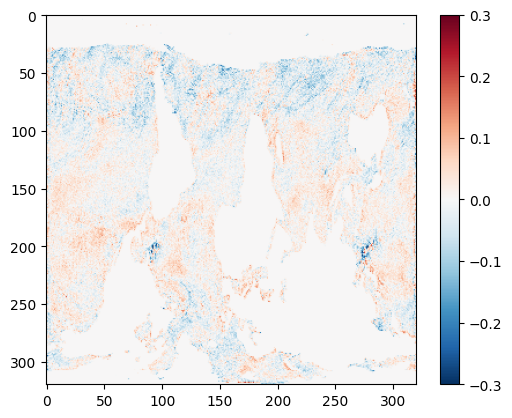

In [37]:
plt.imshow(pred[0,0].detach().cpu().numpy(), cmap='RdBu_r', vmax=0.3, vmin=-0.3)
plt.colorbar()

In [12]:
index = 0
x, f, icymask = test.__getitem__(index)
x = x.unsqueeze(0); f = f.unsqueeze(0); icymask = icymask.unsqueeze(0)
x_truth, x_mean, std, rsample = sample (f, x, icymask, xt=None, n_ensem=1)

/global/u1/j/jiarongw/wavediffusion/src/wavediffusion/wavedata.py:383: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /mscratch/sd/s/swowner/pytorch-build/pytorch/2.6.0/pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  f = torch.from_numpy(self.F_files[file_idx][local_idx]).float()


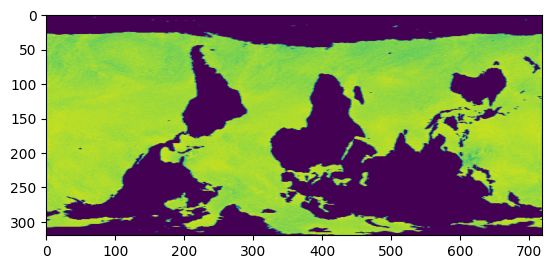

In [13]:
plt.imshow(x_mean[0])

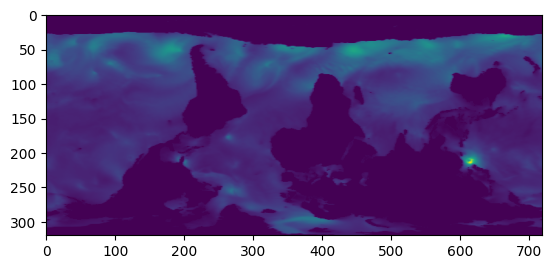

In [11]:
plt.imshow(x_truth[0])